# Month 2: Complex Refractive Index, Absorption, Dispersion, Material Transfer Functions

Month 1 ([`01_maxwell_fourier.ipynb`](01_maxwell_fourier.ipynb)) treated the
complex refractive index $\tilde n = n+i\kappa$ as a single fixed number.
Real materials don't work that way: $n(\omega)$ varies with frequency
(**dispersion**), and by the Kramers-Kronig relations already proved in
`dgs/causality.py`, a dispersive medium **must** also absorb somewhere --
$\mathrm{Re}\,\chi$ and $\mathrm{Im}\,\chi$ are Hilbert-transform pairs, not
independent knobs.

This notebook puts a UV resonance on each polymer from
[`materials.py`](../dgs/microplastic/materials.py), calibrates it against that
polymer's tabulated visible-band index, and builds the resulting material
transfer function $H(\omega)=e^{i\tilde n(\omega)\omega L/c}$ for a real slab
-- the same structural object as the $H(\nu)=e^{i\pi D\nu^2}$ kernel the rest
of this repo does phase retrieval on, but built from a real causal medium
instead of a pure quadratic-phase toy.


In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

from dgs import causality as ca
from dgs.microplastic import physics as phy
from dgs.microplastic import materials as mat
from dgs.microplastic import dispersion as disp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(f"sodium D-line: lambda={disp.LAMBDA_D*1e9:.1f} nm, omega={disp.OMEGA_D:.3e} rad/s")


sodium D-line: lambda=589.3 nm, omega=3.196e+15 rad/s


## §2 The Causal Lorentz Oscillator: One Calibrated Polymer

$$\tilde n(\omega)=\sqrt{1+\chi(\omega)}, \qquad
\chi(\omega)=\frac{\text{strength}}{\omega_0^2-\omega^2-i\gamma\omega}$$

$\omega_0$ sits in the UV ($\lambda_0\approx200$ nm -- typical for a polymer's
electronic transitions, which is exactly why bulk commodity plastics look
transparent across the visible band: you're far from resonance).
`calibrate_strength` solves for the one free parameter (oscillator strength)
so $\mathrm{Re}\,\tilde n$ at the sodium D-line matches `materials.py`'s
tabulated value.

In [2]:
polymer = "PET"
omega0, gamma, strength = disp.polymer_dispersion_model(polymer)
n_at_D = disp.n_tilde_lorentz(disp.OMEGA_D, omega0, gamma, strength)

print(f"{polymer}: omega0={omega0:.3e} rad/s (lambda0={2*np.pi*phy.C/omega0*1e9:.0f} nm)")
print(f"           gamma={gamma:.3e} rad/s")
print(f"           strength={strength:.3e}")
print(f"\nn_tilde(sodium D) = {n_at_D}")
print(f"target n (materials.py) = {mat.refractive_index(polymer)}")
print(f"kappa at the D-line = {n_at_D.imag:.2e}  (small but nonzero -- KK forbids exactly zero)")


PET: omega0=9.418e+15 rad/s (lambda0=200 nm)
           gamma=1.884e+13 rad/s
           strength=1.162e+32

n_tilde(sodium D) = (1.575+0.00036058230619359356j)
target n (materials.py) = 1.575
kappa at the D-line = 3.61e-04  (small but nonzero -- KK forbids exactly zero)


## §3 Calibrate Every Polymer in the Library

In [3]:
rows = []
for poly in mat.list_polymers():
    o0, g, s = disp.polymer_dispersion_model(poly)
    n_fit = disp.n_tilde_lorentz(disp.OMEGA_D, o0, g, s)
    rows.append({
        "polymer": poly,
        "n_target": mat.refractive_index(poly),
        "n_fit": n_fit.real,
        "kappa_at_D": n_fit.imag,
        "strength": s,
    })

df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda x: f"{x:,.6g}")
df


,polymer,n_target,n_fit,kappa_at_D,strength
0,PET,1.575,1.575,0.000360582,1.16209e+32
1,HDPE,1.54,1.54,0.000341623,1.07652e+32
2,PVC,1.54,1.54,0.000341623,1.07652e+32
3,LDPE,1.515,1.515,0.000327923,1.01658e+32
4,PP,1.49,1.49,0.000314086,9.57614e+31
5,PS,1.59,1.59,0.000368633,1.19935e+32
6,ABS,1.54,1.54,0.000341623,1.07652e+32
7,PA6,1.53,1.53,0.000336159,1.05243e+32
8,PC,1.585,1.585,0.000365954,1.18689e+32
9,PLA,1.46,1.46,0.00029729,8.88153e+31


In [4]:
max_err = (df["n_fit"] - df["n_target"]).abs().max()
print(f"max |n_fit - n_target| across all polymers: {max_err:.2e}  (calibration is exact to solver tolerance)")


max |n_fit - n_target| across all polymers: 2.22e-16  (calibration is exact to solver tolerance)


## §4 Dispersion Curves Across Visible + Near-UV

Plot $n(\lambda)$ and $\kappa(\lambda)$ for a few polymers from 350-750 nm.
Every curve rises toward the UV resonance (**normal dispersion** -- the
textbook behavior away from an absorption line) and $\kappa$ grows fastest for
the polymers whose calibrated oscillator strength was largest (PS, PC --
the highest-index, most "optically dense" plastics in the table).

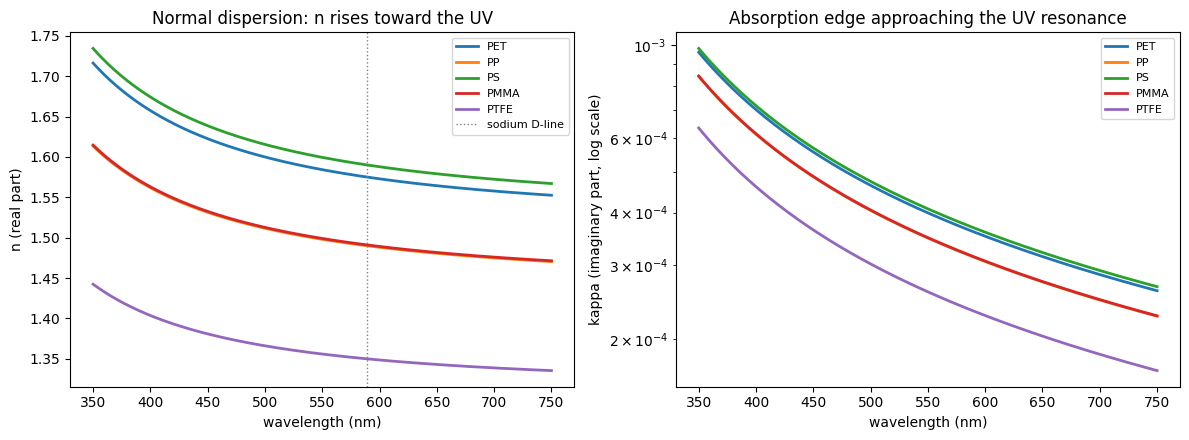

In [5]:
lam_nm = np.linspace(350, 750, 300)
omega_arr = 2*np.pi*phy.C / (lam_nm*1e-9)

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
polymers_to_plot = ["PET", "PP", "PS", "PMMA", "PTFE"]
for poly in polymers_to_plot:
    o0, g, s = disp.polymer_dispersion_model(poly)
    n_tilde = disp.n_tilde_lorentz(omega_arr, o0, g, s)
    axes[0].plot(lam_nm, n_tilde.real, lw=2, label=poly)
    axes[1].semilogy(lam_nm, n_tilde.imag, lw=2, label=poly)

axes[0].axvline(589.3, color='gray', ls=':', lw=1, label='sodium D-line')
axes[0].set_xlabel("wavelength (nm)"); axes[0].set_ylabel("n (real part)")
axes[0].set_title("Normal dispersion: n rises toward the UV")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("wavelength (nm)"); axes[1].set_ylabel("kappa (imaginary part, log scale)")
axes[1].set_title("Absorption edge approaching the UV resonance")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("02_dispersion_curves.png", dpi=90)
plt.show()


## §5 Kramers-Kronig: Dispersion and Absorption Are Not Independent

`dgs/causality.py` already proved $\mathrm{Re}\,\chi=-\mathcal H[\mathrm{Im}\,\chi]$
for a general causal response. This model's $\chi(\omega)$ is a Lorentz
oscillator -- causal by construction -- so it must satisfy that relation
exactly. Verify it numerically rather than just citing month 1's causality
module.

PS: max relative error, Re(chi) reconstructed from Im(chi) via Hilbert transform: 0.05%


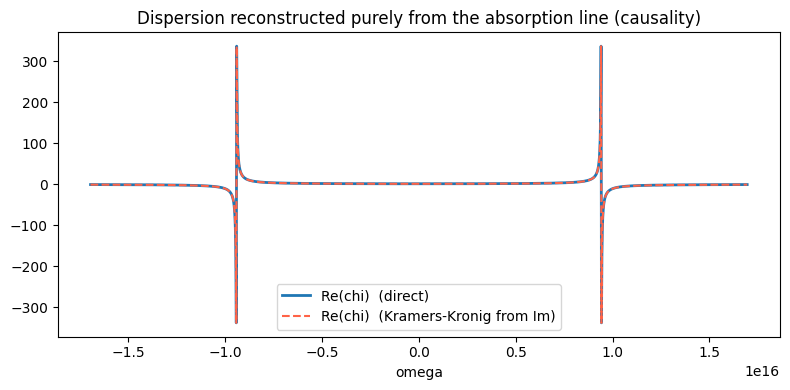

In [6]:
o0, g, s = disp.polymer_dispersion_model("PS")
w = np.linspace(-3*o0, 3*o0, 20000)
chi = ca.lorentz_susceptibility(w, o0, g, s)

Re_kk = ca.kramers_kronig_real(chi.imag)
core = slice(4000, 16000)   # interior of the grid, away from FFT edge artifacts
rel_err = np.max(np.abs(chi.real[core] - Re_kk[core])) / np.max(np.abs(chi.real[core]))
print(f"PS: max relative error, Re(chi) reconstructed from Im(chi) via Hilbert transform: {rel_err:.2%}")

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(w[core], chi.real[core], lw=2, label="Re(chi)  (direct)")
ax.plot(w[core], Re_kk[core], lw=1.5, ls='--', color='tomato', label="Re(chi)  (Kramers-Kronig from Im)")
ax.set_xlabel("omega"); ax.legend()
ax.set_title("Dispersion reconstructed purely from the absorption line (causality)")
plt.tight_layout()
plt.savefig("02_kramers_kronig.png", dpi=90)
plt.show()


## §6 Material Transfer Function: A Real Pulse Through a Real Slab

$$H(\omega)=e^{i\tilde n(\omega)\,\omega L/c}$$

This needs **real physical units**, not month 1's arbitrary demo time axis --
$\tilde n(\omega)$ was calibrated at real optical frequencies
($\omega_0\sim10^{15}$ rad/s), so the pulse has to actually carry spectral
content there: a femtosecond-scale envelope riding a carrier at the sodium
D-line, not a baseband pulse near $\omega=0$ (which would sit nowhere near
the resonance and show no dispersion or absorption at all -- an easy mistake
to make with month 1's toy units, caught here rather than silently shipped).
L is a few hundred microns -- a single microplastic particle's own path
length, per `materials.py`, not an arbitrary lab-bench slab.

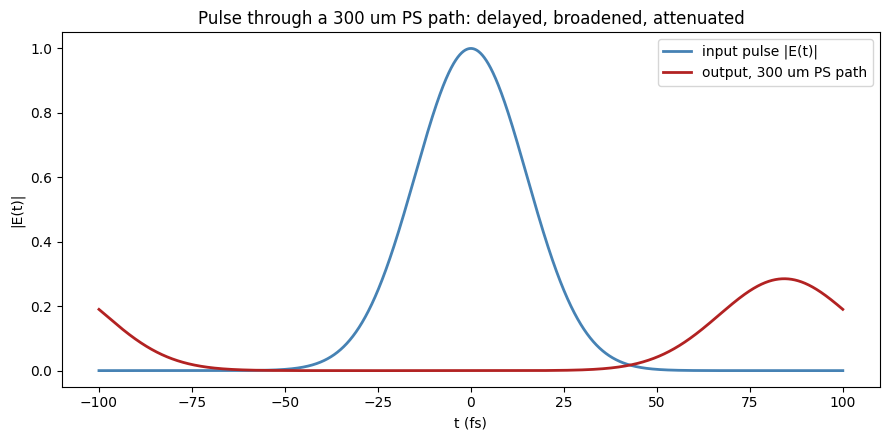

peak amplitude reduction over 300 um of PS: 71.48%


In [7]:
poly = "PS"
o0, g, s = disp.polymer_dispersion_model(poly)
n_fn = lambda om: disp.n_tilde_lorentz(om, o0, g, s)

fs = 1e-15
t = np.linspace(-100*fs, 100*fs, 20000)     # +/- 100 fs, real seconds
tau = 15*fs                                  # 15 fs envelope
Et_in = phy.gaussian_pulse(t, tau=tau, omega0=disp.OMEGA_D)   # carrier at the D-line

L = 300e-6   # 300 micron path -- microplastic-particle scale, not a lab slab
t_out, Et_out = disp.apply_slab(t, Et_in, n_fn, L)

fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(t/fs, np.abs(Et_in), lw=2, color="steelblue", label="input pulse |E(t)|")
ax.plot(t_out/fs, np.abs(Et_out), lw=2, color="firebrick", label=f"output, {L*1e6:.0f} um {poly} path")
ax.set_xlabel("t (fs)"); ax.set_ylabel("|E(t)|")
ax.legend()
ax.set_title(f"Pulse through a {L*1e6:.0f} um {poly} path: delayed, broadened, attenuated")
plt.tight_layout()
plt.savefig("02_pulse_through_slab.png", dpi=90)
plt.show()

peak_reduction = 1 - np.max(np.abs(Et_out))/np.max(np.abs(Et_in))
print(f"peak amplitude reduction over {L*1e6:.0f} um of {poly}: {peak_reduction:.2%}")


## §7 Compare Pulse Distortion Across the Polymer Library

In [8]:
rows2 = []
for poly in mat.list_polymers():
    o0, g, s = disp.polymer_dispersion_model(poly)
    n_fn_p = lambda om, o0=o0, g=g, s=s: disp.n_tilde_lorentz(om, o0, g, s)
    t_o, Et_o = disp.apply_slab(t, Et_in, n_fn_p, L)
    rows2.append({
        "polymer": poly,
        "peak_reduction_pct": (1 - np.max(np.abs(Et_o))/np.max(np.abs(Et_in))) * 100,
        "n_at_D": mat.refractive_index(poly),
    })

df2 = pd.DataFrame(rows2).sort_values("peak_reduction_pct", ascending=False).reset_index(drop=True)
print(f"(all rows use the same {L*1e6:.0f} um path length as SS6)")
df2


(all rows use the same 300 um path length as SS6)


,polymer,peak_reduction_pct,n_at_D
0,PS,71.4818,1.59
1,PC,71.2099,1.585
2,PET,70.6572,1.575
3,HDPE,68.6236,1.54
4,ABS,68.6236,1.54
5,PVC,68.6236,1.54
6,PA6,68.0128,1.53
7,LDPE,67.0704,1.515
8,PMMA,65.4944,1.491
9,PP,65.4269,1.49


## §8 Connection to $H(\nu)=e^{i\pi D\nu^2}$

The rest of this repo's phase-retrieval work inverts a *pure quadratic-phase*
transfer function -- a mathematical idealization of a dispersive fiber, valid
near one operating wavelength. This notebook's $H(\omega)$ is the more
general, physically complete object it's approximating: a real causal medium
with a resonance, where the quadratic-phase behavior is just the local
Taylor expansion of $\tilde n(\omega)\omega$ near the operating frequency, far
from resonance. It's also why a real dispersive fiber always has *some* loss
-- Kramers-Kronig makes it structurally impossible to have dispersion (the
whole point of the D parameter) without absorption riding along with it
somewhere in the spectrum.

## §9 Where This Goes Next

| Month | Topic |
|-------|-------|
| 3 | Gaussian/THz pulse propagation through dispersive media (this notebook's §6, generalized) |
| 4 | Particle-scattering model, synthetic microplastic concentration experiments |
| 5 | Detector, noise, ADC resolution, sampling, FFT, uncertainty analysis |
| 6 | PyTorch inverse model: estimate material parameters from simulated spectra |
| 7 | Temperature dependence, statistical validation, PCA vs conventional estimators |
| 8 | Reproducibility, documentation, figures, cost model, research presentation |
